# Restaurant Complaint Severity Prediction
### Custom Transformer Built From Scratch with PyTorch

Predicts complaint severity (`Low`, `Medium`, `High`, `Critical`) from free-text
restaurant reviews (`review_text`). The classifier is a Transformer encoder
implemented entirely from native PyTorch modules — no BERT, no Hugging Face,
no pretrained weights, no transfer learning.

**Pipeline:** data inspection → validation → EDA → leakage checks → text
preprocessing → label encoding → stratified splits → TF-IDF baselines →
cross-validation → vocabulary → custom Transformer → training → evaluation →
severity/error analysis → model comparison → artifact export → inference
helpers → deployment (Flask / FastAPI / Render / Vercel) → requirements.


In [44]:
import os
import re
import json
import time
import pickle
import random
import warnings
import unicodedata
from collections import Counter
from itertools import islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = "/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Complaints.csv"
ARTIFACT_DIR = "Model/Severity_Prediction/artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Environment ready.")
print("PyTorch version:", torch.__version__)


Environment ready.
PyTorch version: 2.2.2


## Phase 1 — Data Inspection


In [45]:
df = pd.read_csv("/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Complaints.csv")

print("Dataset Shape:", df.shape)
print()
print("Columns:", list(df.columns))
print()
print("Data Types:")
print(df.dtypes)


Dataset Shape: (10800, 6)

Columns: ['review_id', 'review_text', 'complaint_label', 'severity_label', 'stars', 'sentiment_label']

Data Types:
review_id          object
review_text        object
complaint_label    object
severity_label     object
stars               int64
sentiment_label    object
dtype: object


In [46]:
print("Missing Values:")
print(df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Reviews (review_text):", df["review_text"].duplicated().sum())
print()
print("Unique Severity Classes:", sorted(df["severity_label"].dropna().unique().tolist()))
print()
print("Class Distribution:")
print(df["severity_label"].value_counts())
print()
print("Class Distribution (%):")
print((df["severity_label"].value_counts(normalize=True) * 100).round(2))


Missing Values:
review_id          0
review_text        0
complaint_label    0
severity_label     0
stars              0
sentiment_label    0
dtype: int64

Duplicate Rows: 0
Duplicate Reviews (review_text): 0

Unique Severity Classes: ['Critical', 'High', 'Low', 'Medium']

Class Distribution:
severity_label
Critical    2700
Medium      2700
High        2700
Low         2700
Name: count, dtype: int64

Class Distribution (%):
severity_label
Critical    25.0
Medium      25.0
High        25.0
Low         25.0
Name: proportion, dtype: float64


In [47]:
print("Sample Records:")
display(df.sample(5, random_state=SEED))
print()
print("Memory Usage:")
print(df.memory_usage(deep=True))
print()
print("Total memory (MB):", round(df.memory_usage(deep=True).sum() / (1024 ** 2), 3))


Sample Records:


,review_id,review_text,complaint_label,severity_label,stars,sentiment_label
1254,RC001255,"Honestly, the ramen bowl was undercooked and s...",Food Quality,High,1,Negative
9033,RC009034,"Overall, a fairly middle-of-the-road visit, so...",General Dissatisfaction,Low,3,Neutral
2523,RC002524,The delivery from the food delivery app arrive...,Service Delay,Low,5,Positive
10670,RC010671,I specifically asked for no onions in my chees...,Food Quality,Critical,1,Negative
8637,RC008638,The card machine at the hotel wasn't working p...,Pricing Issue,Medium,3,Neutral



Memory Usage:
Index                  132
review_id           702000
review_text        2706678
complaint_label     781200
severity_label      672300
stars                86400
sentiment_label     700046
dtype: int64

Total memory (MB): 5.387


In [48]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique(),
})
print("Complete Dataset Summary")
display(summary)


Complete Dataset Summary


,dtype,missing,missing_pct,n_unique
review_id,object,0,0.0,10800
review_text,object,0,0.0,10800
complaint_label,object,0,0.0,6
severity_label,object,0,0.0,4
stars,int64,0,0.0,5
sentiment_label,object,0,0.0,3


## Phase 2 — Data Validation


In [49]:
VALID_LABELS = {"Low", "Medium", "High", "Critical"}

validation_report = {}
validation_report["null_review_text"] = int(df["review_text"].isnull().sum())
validation_report["null_severity_label"] = int(df["severity_label"].isnull().sum())
validation_report["empty_reviews"] = int((df["review_text"].astype(str).str.strip() == "").sum())
validation_report["duplicate_reviews"] = int(df["review_text"].duplicated().sum())
validation_report["duplicate_rows"] = int(df.duplicated().sum())
validation_report["invalid_severity_labels"] = int(
    (~df["severity_label"].isin(VALID_LABELS)).sum()
)

review_lengths_words = df["review_text"].astype(str).str.split().apply(len)
SHORT_THRESHOLD = 3
LONG_THRESHOLD = int(review_lengths_words.quantile(0.99))
validation_report["extremely_short_reviews (<%d words)" % SHORT_THRESHOLD] = int(
    (review_lengths_words < SHORT_THRESHOLD).sum()
)
validation_report["extremely_long_reviews (>%d words, p99)" % LONG_THRESHOLD] = int(
    (review_lengths_words > LONG_THRESHOLD).sum()
)

class_counts = df["severity_label"].value_counts()
validation_report["class_imbalance_ratio (max/min)"] = round(
    float(class_counts.max() / class_counts.min()), 3
)

print("VALIDATION REPORT")
print("=" * 50)
for k, v in validation_report.items():
    print(f"{k:55s}: {v}")


VALIDATION REPORT
null_review_text                                       : 0
null_severity_label                                    : 0
empty_reviews                                          : 0
duplicate_reviews                                      : 0
duplicate_rows                                         : 0
invalid_severity_labels                                : 0
extremely_short_reviews (<3 words)                     : 0
extremely_long_reviews (>75 words, p99)                : 101
class_imbalance_ratio (max/min)                        : 1.0


In [50]:
# Drop rows with null/empty review_text or invalid severity labels before proceeding
before = len(df)
df = df[df["review_text"].notnull()]
df = df[df["review_text"].astype(str).str.strip() != ""]
df = df[df["severity_label"].isin(VALID_LABELS)]
df = df.drop_duplicates(subset=["review_text"]).reset_index(drop=True)
after = len(df)
print(f"Rows before cleaning: {before} | after cleaning: {after} | removed: {before - after}")


Rows before cleaning: 10800 | after cleaning: 10800 | removed: 0


## Phase 3 — Exploratory Data Analysis


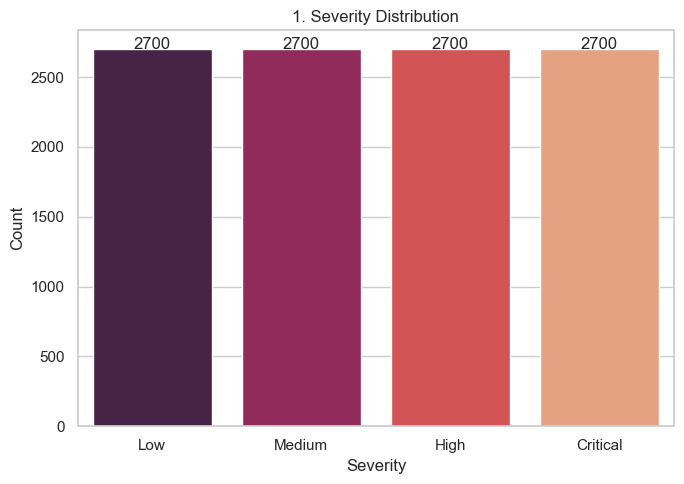

In [51]:
SEVERITY_ORDER = ["Low", "Medium", "High", "Critical"]

df["character_count"] = df["review_text"].astype(str).apply(len)
df["word_count"] = df["review_text"].astype(str).apply(lambda t: len(t.split()))
df["sentence_count"] = df["review_text"].astype(str).apply(
    lambda t: max(1, len(re.split(r"[.!?]+", t.strip())) - (1 if t.strip().endswith((".", "!", "?")) else 0))
)
df["review_length"] = df["character_count"]

fig, ax = plt.subplots(figsize=(7, 5))
order_counts = df["severity_label"].value_counts().reindex(SEVERITY_ORDER)
sns.barplot(x=order_counts.index, y=order_counts.values, hue=order_counts.index,
            palette="rocket", legend=False, ax=ax)
ax.set_title("1. Severity Distribution")
ax.set_xlabel("Severity")
ax.set_ylabel("Count")
for i, v in enumerate(order_counts.values):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()


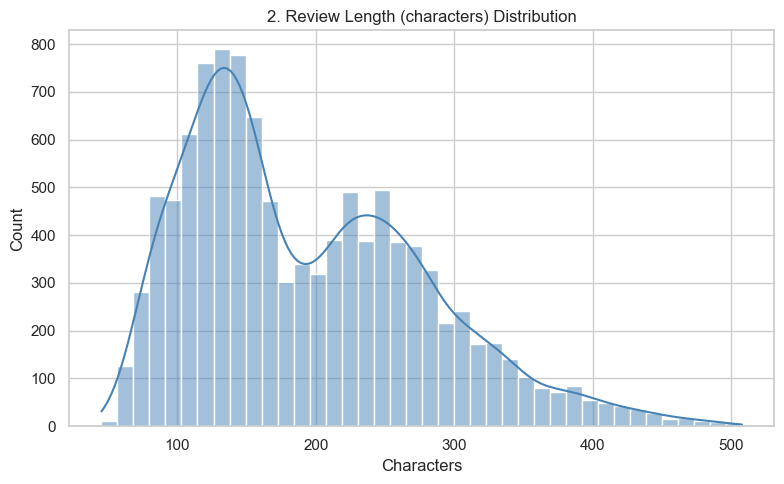

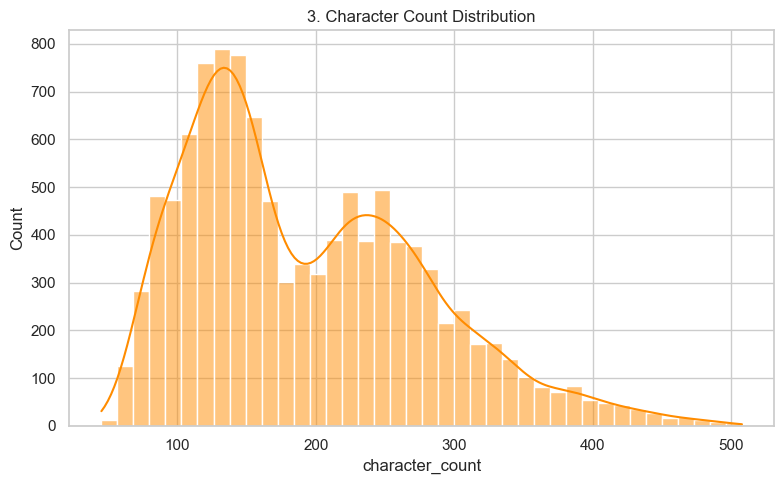

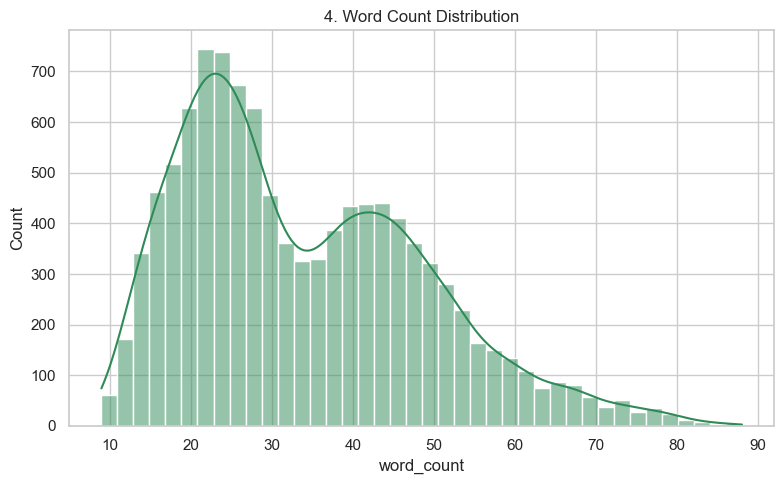

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["review_length"], bins=40, kde=True, color="steelblue", ax=ax)
ax.set_title("2. Review Length (characters) Distribution")
ax.set_xlabel("Characters")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["character_count"], bins=40, kde=True, color="darkorange", ax=ax)
ax.set_title("3. Character Count Distribution")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["word_count"], bins=40, kde=True, color="seagreen", ax=ax)
ax.set_title("4. Word Count Distribution")
plt.tight_layout()
plt.show()


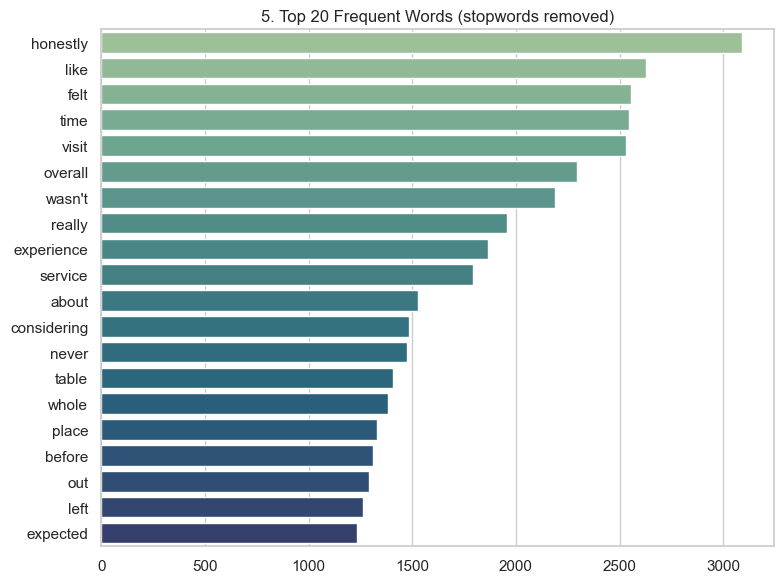

In [53]:
STOPWORDS = set('''a an the and or but if is are was were be been being to of in on
for with as by at from this that these those it its it's i you he she we they
them his her our your their not no do does did have has had can could will
would should just so than then there here what which who whom my me us'''.split())


def tokenize(text):
    text = str(text).lower()
    return re.findall(r"[a-z']+", text)


all_tokens = []
for t in df["review_text"]:
    all_tokens.extend([w for w in tokenize(t) if w not in STOPWORDS and len(w) > 2])

word_freq = Counter(all_tokens)
top_words = word_freq.most_common(20)

fig, ax = plt.subplots(figsize=(8, 6))
words, counts = zip(*top_words)
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="crest", legend=False, ax=ax)
ax.set_title("5. Top 20 Frequent Words (stopwords removed)")
plt.tight_layout()
plt.show()


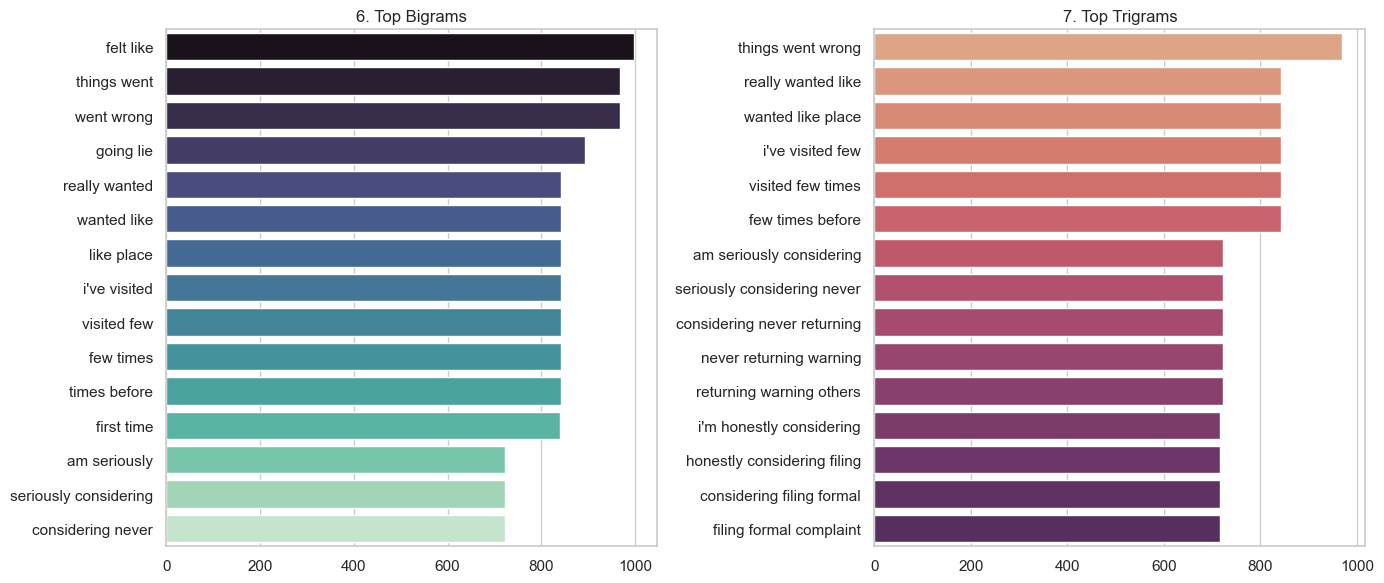

In [54]:
def ngrams(tokens, n):
    return zip(*[islice(tokens, i, None) for i in range(n)])


bigram_counter = Counter()
trigram_counter = Counter()
for t in df["review_text"]:
    toks = [w for w in tokenize(t) if w not in STOPWORDS]
    bigram_counter.update(" ".join(g) for g in ngrams(toks, 2))
    trigram_counter.update(" ".join(g) for g in ngrams(toks, 3))

top_bigrams = bigram_counter.most_common(15)
top_trigrams = trigram_counter.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
b_labels, b_counts = zip(*top_bigrams)
sns.barplot(x=list(b_counts), y=list(b_labels), hue=list(b_labels), palette="mako", legend=False, ax=axes[0])
axes[0].set_title("6. Top Bigrams")

t_labels, t_counts = zip(*top_trigrams)
sns.barplot(x=list(t_counts), y=list(t_labels), hue=list(t_labels), palette="flare", legend=False, ax=axes[1])
axes[1].set_title("7. Top Trigrams")
plt.tight_layout()
plt.show()


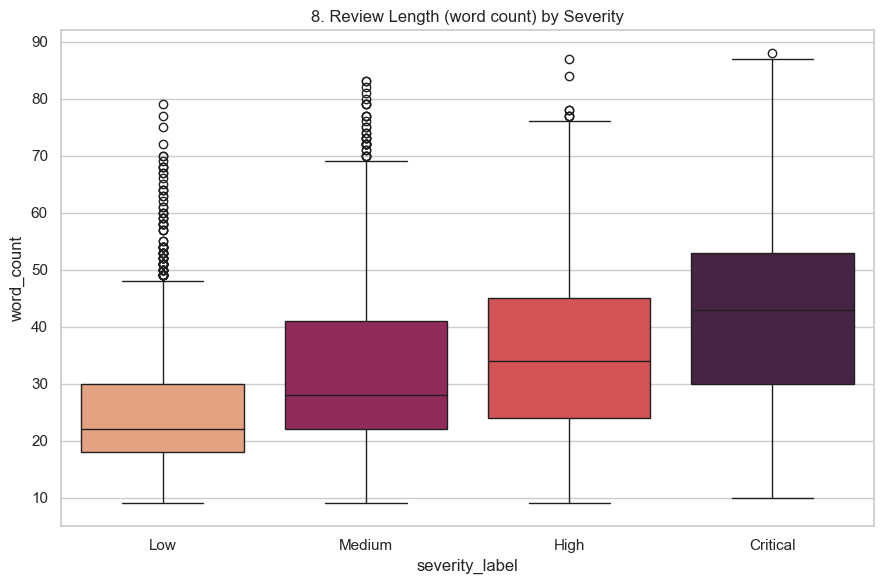

In [55]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x="severity_label", y="word_count", order=SEVERITY_ORDER, hue="severity_label",
            palette="rocket", legend=False, ax=ax)
ax.set_title("8. Review Length (word count) by Severity")
plt.tight_layout()
plt.show()


In [56]:
text_stats = df.groupby("severity_label")[["character_count", "word_count", "sentence_count"]].agg(
    ["mean", "median", "std", "min", "max"]
).reindex(SEVERITY_ORDER)
print("9. Text Statistics by Severity")
display(text_stats)


9. Text Statistics by Severity


character_count                            word_count         \
                          mean median        std min  max       mean median   
severity_label                                                                
Low                 146.330370  131.0  60.144057  55  435  25.083704   22.0   
Medium              178.021852  157.0  74.547845  45  455  31.997037   28.0   
High                198.206296  190.0  80.125032  55  485  35.320741   34.0   
Critical            251.914815  251.0  90.587385  58  508  43.147037   43.0   

                                  sentence_count                           
                      std min max           mean median       std min max  
severity_label                                                             
Low             10.670884   9  79       2.132963    2.0  0.985118   1   6  
Medium          13.529762   9  83       2.514815    2.0  1.149513   1   6  
High            14.269910   9  87       2.765556    3.0  1.199388   1   6  
Critical        15.338669  10  88       3.143333    3.0  1.185551   1   6

In [57]:
balance_report = pd.DataFrame({
    "count": df["severity_label"].value_counts().reindex(SEVERITY_ORDER),
    "pct": (df["severity_label"].value_counts(normalize=True) * 100).round(2).reindex(SEVERITY_ORDER),
})
balance_report["imbalance_vs_majority"] = round(
    balance_report["count"].max() / balance_report["count"], 3
)
print("10. Severity Balance Report")
display(balance_report)


10. Severity Balance Report


,count,pct,imbalance_vs_majority
severity_label,,,
Low,2700,25.0,1.0
Medium,2700,25.0,1.0
High,2700,25.0,1.0
Critical,2700,25.0,1.0


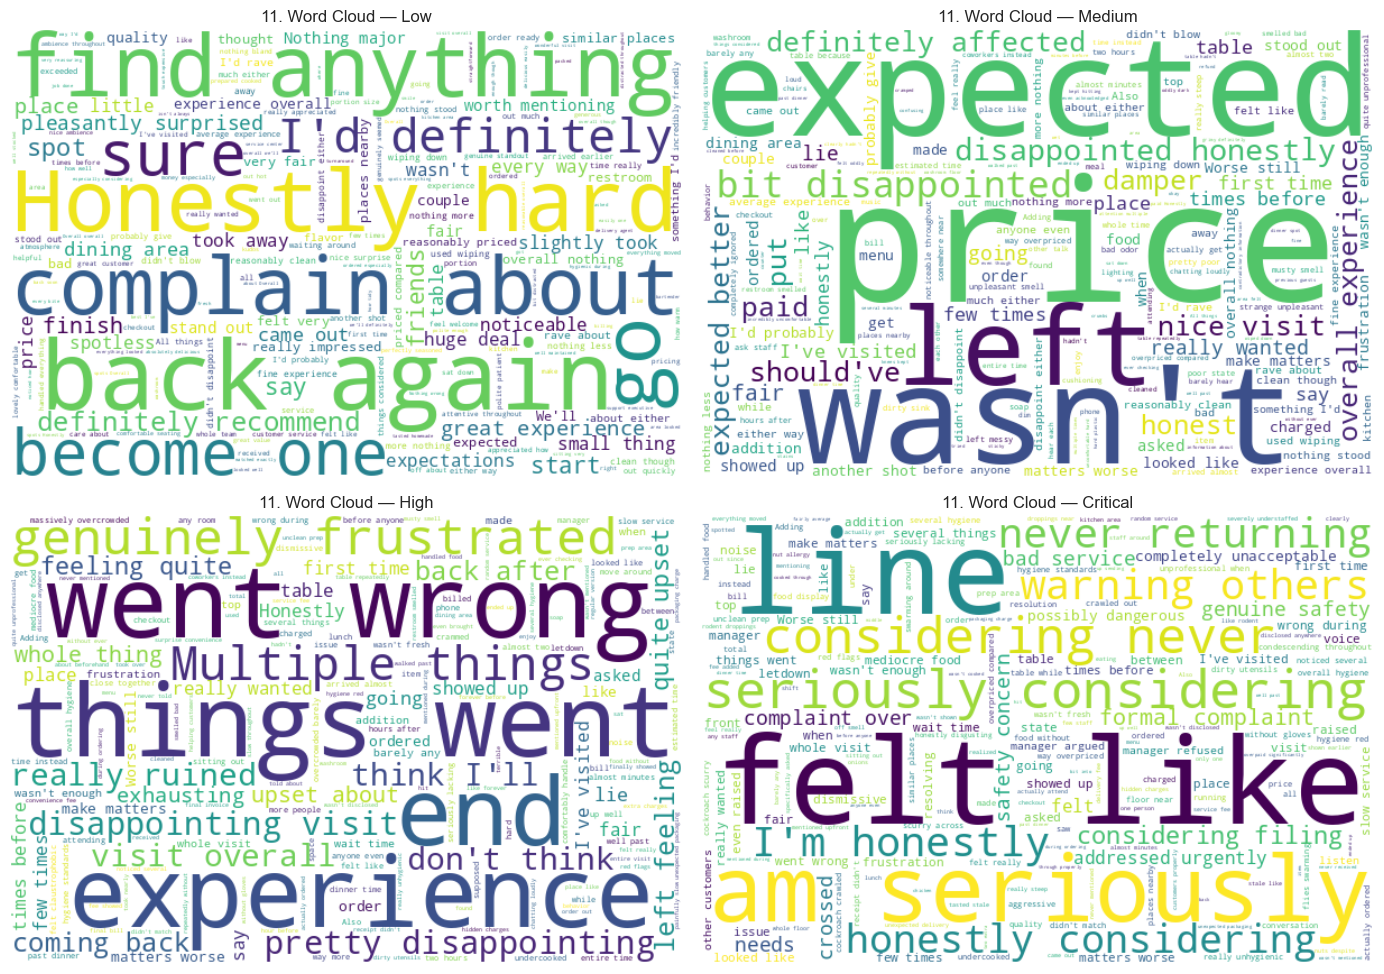

In [58]:
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, sev in zip(axes.ravel(), SEVERITY_ORDER):
        text_blob = " ".join(df.loc[df["severity_label"] == sev, "review_text"].astype(str))
        wc = WordCloud(width=600, height=400, background_color="white",
                        stopwords=STOPWORDS, colormap="viridis").generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"11. Word Cloud — {sev}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("wordcloud not available — skipping word cloud generation.")


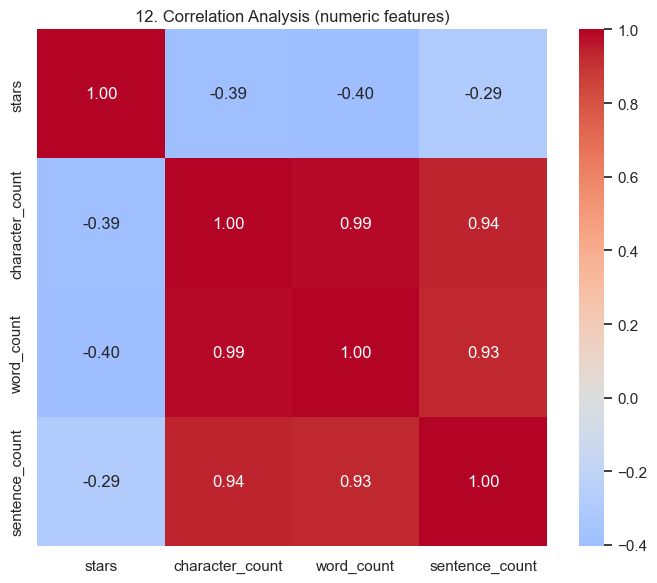

In [59]:
numeric_cols = ["stars", "character_count", "word_count", "sentence_count"]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("12. Correlation Analysis (numeric features)")
plt.tight_layout()
plt.show()


## Phase 4 — Leakage Detection


In [60]:
print("LEAKAGE REPORT")
print("=" * 60)

# review_id: purely an identifier, no informational relationship to severity
print("review_id -> unique per row:", df["review_id"].is_unique, "(no signal, drop)")

# complaint_label: a category, check association strength (not identity) with severity
ct = pd.crosstab(df["complaint_label"], df["severity_label"])
print()
print("complaint_label vs severity_label crosstab (does NOT determine label 1:1):")
display(ct)

# stars: ordinal rating, check whether stars maps deterministically to severity
stars_map = df.groupby("stars")["severity_label"].nunique()
print()
print("Unique severity labels per star rating (》1 means stars alone doesn't leak severity):")
print(stars_map)

# sentiment_label: coarse category, check determinism
sent_map = df.groupby("sentiment_label")["severity_label"].nunique()
print()
print("Unique severity labels per sentiment_label:")
print(sent_map)

print()
print("Conclusion: complaint_label, stars, and sentiment_label are correlated with")
print("severity (as expected — they are proxies for how bad an experience was) but")
print("none deterministically reveals severity_label (each maps to multiple classes).")
print("They are still excluded from model input to keep the task an honest text-only")
print("classification problem — only `review_text` is used.")


LEAKAGE REPORT
review_id -> unique per row: True (no signal, drop)

complaint_label vs severity_label crosstab (does NOT determine label 1:1):


severity_label,Critical,High,Low,Medium
complaint_label,,,,
Cleanliness Issue,450,450,450,450
Food Quality,450,450,450,450
General Dissatisfaction,450,450,450,450
Pricing Issue,450,450,450,450
Service Delay,450,450,450,450
Staff Behavior,450,450,450,450



Unique severity labels per star rating (》1 means stars alone doesn't leak severity):
stars
1    2
2    3
3    2
4    2
5    1
Name: severity_label, dtype: int64

Unique severity labels per sentiment_label:
sentiment_label
Negative    4
Neutral     2
Positive    1
Name: severity_label, dtype: int64

Conclusion: complaint_label, stars, and sentiment_label are correlated with
severity (as expected — they are proxies for how bad an experience was) but
none deterministically reveals severity_label (each maps to multiple classes).
They are still excluded from model input to keep the task an honest text-only
classification problem — only `review_text` is used.


In [61]:
LEAKAGE_COLUMNS = ["review_id", "complaint_label", "stars", "sentiment_label"]
model_df = df[["review_text", "severity_label"]].copy()
print("Model input columns:", list(model_df.columns))
print("Leakage columns removed:", LEAKAGE_COLUMNS)


Model input columns: ['review_text', 'severity_label']
Leakage columns removed: ['review_id', 'complaint_label', 'stars', 'sentiment_label']


## Phase 5 — Text Preprocessing


In [62]:
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
MULTISPACE_RE = re.compile(r"\s+")
SPECIAL_CHARS_RE = re.compile(r"[^a-z0-9\s.,!?'\-]")


def clean_text(text):
    text = str(text)
    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = SPECIAL_CHARS_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


model_df["clean_text"] = model_df["review_text"].apply(clean_text)
print("Sample cleaned text:")
for i in range(3):
    print("-" * 60)
    print("RAW  :", model_df["review_text"].iloc[i][:160])
    print("CLEAN:", model_df["clean_text"].iloc[i][:160])


Sample cleaned text:
------------------------------------------------------------
RAW  : Honestly, several things went wrong during our visit, from the wait time to the state of our table. I felt this was completely unacceptable and possibly dangero
CLEAN: honestly, several things went wrong during our visit, from the wait time to the state of our table. i felt this was completely unacceptable and possibly dangero
------------------------------------------------------------
RAW  : The water park was reasonably clean, though a couple of tables could have used wiping down. It didn't blow me away, but it didn't disappoint either.
CLEAN: the water park was reasonably clean, though a couple of tables could have used wiping down. it didn't blow me away, but it didn't disappoint either.
------------------------------------------------------------
RAW  : I really wanted to like this place, but the ice cream sundae had ingredients I didn't order and hadn't asked for. I felt this was completely 

## Phase 6 — Feature Engineering Analysis (analysis-only, not fed to the Transformer)


In [63]:
feat_df = model_df.copy()
feat_df["review_length"] = feat_df["clean_text"].apply(len)
feat_df["word_count"] = feat_df["clean_text"].apply(lambda t: len(t.split()))
feat_df["character_count"] = feat_df["clean_text"].apply(len)
feat_df["sentence_count"] = feat_df["review_text"].apply(
    lambda t: max(1, len(re.split(r"[.!?]+", str(t).strip())))
)
feat_df["average_word_length"] = feat_df["clean_text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)

display(feat_df.groupby(model_df["severity_label"])[
    ["review_length", "word_count", "character_count", "sentence_count", "average_word_length"]
].mean().reindex(SEVERITY_ORDER).round(2))

print()
print("These engineered features are for ANALYSIS ONLY.")
print("The Transformer's only input is `clean_text` (derived from review_text).")


,review_length,word_count,character_count,sentence_count,average_word_length
severity_label,,,,,
Low,146.33,25.08,146.33,3.13,4.93
Medium,178.02,32.00,178.02,3.51,4.63
High,198.21,35.33,198.21,3.77,4.66
Critical,251.91,43.17,251.91,4.14,4.86



These engineered features are for ANALYSIS ONLY.
The Transformer's only input is `clean_text` (derived from review_text).


## Phase 7 — Label Encoding


In [64]:
SEVERITY_TO_ID = {label: idx for idx, label in enumerate(SEVERITY_ORDER)}
ID_TO_SEVERITY = {idx: label for label, idx in SEVERITY_TO_ID.items()}

label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(SEVERITY_ORDER)

model_df["label_id"] = model_df["severity_label"].map(SEVERITY_TO_ID)

with open(os.path.join(ARTIFACT_DIR, "severity_label_encoder.pkl"), "wb") as f:
    pickle.dump({
        "label_encoder": label_encoder,
        "label_to_id": SEVERITY_TO_ID,
        "id_to_label": ID_TO_SEVERITY,
    }, f)

print("Label mapping:", SEVERITY_TO_ID)
print("Saved severity_label_encoder.pkl")


Label mapping: {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
Saved severity_label_encoder.pkl


## Phase 8 — Train / Validation / Test Split (70/15/15, stratified)


In [65]:
train_df, temp_df = train_test_split(
    model_df, test_size=0.30, stratify=model_df["label_id"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} ({len(train_df)/len(model_df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(model_df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(model_df)*100:.1f}%)")

split_dist = pd.DataFrame({
    "train_pct": (train_df["severity_label"].value_counts(normalize=True) * 100).round(2),
    "val_pct": (val_df["severity_label"].value_counts(normalize=True) * 100).round(2),
    "test_pct": (test_df["severity_label"].value_counts(normalize=True) * 100).round(2),
}).reindex(SEVERITY_ORDER)
print()
print("Class balance preserved across splits:")
display(split_dist)


Train: 7560 (70.0%)
Val:   1620 (15.0%)
Test:  1620 (15.0%)

Class balance preserved across splits:


,train_pct,val_pct,test_pct
severity_label,,,
Low,25.0,25.0,25.0
Medium,25.0,25.0,25.0
High,25.0,25.0,25.0
Critical,25.0,25.0,25.0


## Phase 9 — Traditional NLP Baselines (TF-IDF)


In [66]:
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["clean_text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_text"])

y_train = train_df["label_id"].values
y_val = val_df["label_id"].values
y_test = test_df["label_id"].values

print("TF-IDF matrix shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)


TF-IDF matrix shapes: (7560, 6071) (1620, 6071) (1620, 6071)


In [67]:
def evaluate_predictions(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    result = {
        "model": model_name,
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
    }
    print(f"--- {model_name} ---")
    for k, v in result.items():
        if k != "model":
            print(f"  {k:12s}: {v}")
    print()
    print(classification_report(y_true, y_pred, target_names=SEVERITY_ORDER, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER, ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()
    return result


baseline_results = []


--- TF-IDF + Logistic Regression ---
  accuracy    : 0.8994
  precision   : 0.9001
  recall      : 0.8994
  f1          : 0.8993
  macro_f1    : 0.8993
  weighted_f1 : 0.8993

              precision    recall  f1-score   support

         Low       0.87      0.94      0.91       405
      Medium       0.84      0.82      0.83       405
        High       0.91      0.90      0.91       405
    Critical       0.97      0.93      0.95       405

    accuracy                           0.90      1620
   macro avg       0.90      0.90      0.90      1620
weighted avg       0.90      0.90      0.90      1620



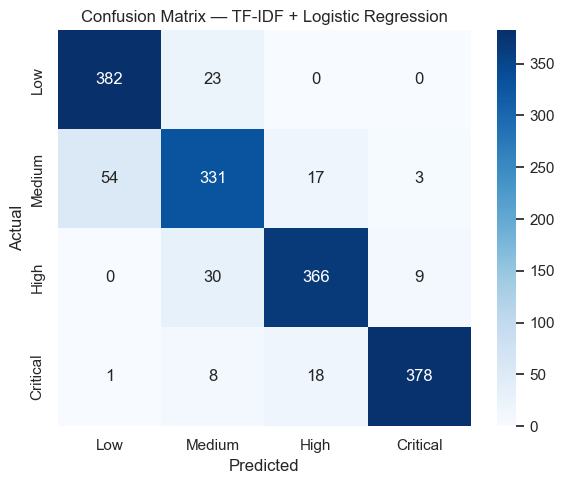

In [68]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
log_reg.fit(X_train_tfidf, y_train)
pred_lr = log_reg.predict(X_test_tfidf)
baseline_results.append(evaluate_predictions(y_test, pred_lr, "TF-IDF + Logistic Regression"))


--- TF-IDF + Random Forest ---
  accuracy    : 0.8802
  precision   : 0.8883
  recall      : 0.8802
  f1          : 0.8813
  macro_f1    : 0.8813
  weighted_f1 : 0.8813

              precision    recall  f1-score   support

         Low       0.80      0.96      0.87       405
      Medium       0.81      0.82      0.82       405
        High       0.95      0.84      0.89       405
    Critical       0.99      0.90      0.94       405

    accuracy                           0.88      1620
   macro avg       0.89      0.88      0.88      1620
weighted avg       0.89      0.88      0.88      1620



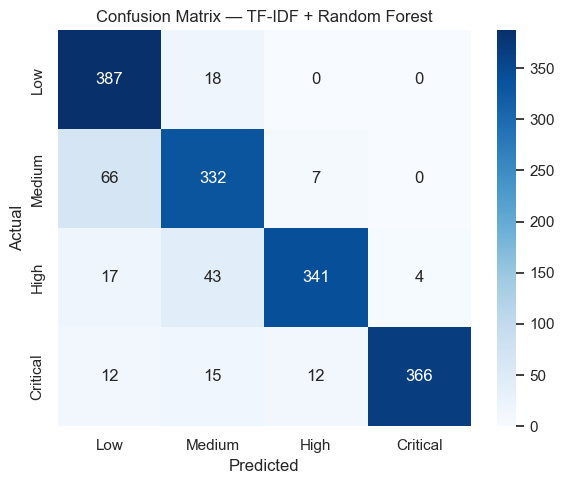

In [69]:
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=30, class_weight="balanced", random_state=SEED, n_jobs=-1
)
random_forest.fit(X_train_tfidf, y_train)
pred_rf = random_forest.predict(X_test_tfidf)
baseline_results.append(evaluate_predictions(y_test, pred_rf, "TF-IDF + Random Forest"))


## Phase 10 — 5-Fold Stratified Cross Validation (Logistic Regression)


In [70]:
X_full_tfidf = tfidf_vectorizer.transform(model_df["clean_text"])
y_full = model_df["label_id"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = cross_validate(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    X_full_tfidf, y_full, cv=skf,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1,
)

print("5-Fold Stratified Cross Validation — Logistic Regression")
print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  (std {cv_results['test_accuracy'].std():.4f})")
print(f"Mean Macro F1: {cv_results['test_f1_macro'].mean():.4f}  (std {cv_results['test_f1_macro'].std():.4f})")

cv_summary = {
    "mean_accuracy": float(cv_results["test_accuracy"].mean()),
    "std_accuracy": float(cv_results["test_accuracy"].std()),
    "mean_f1_macro": float(cv_results["test_f1_macro"].mean()),
    "std_f1_macro": float(cv_results["test_f1_macro"].std()),
}


5-Fold Stratified Cross Validation — Logistic Regression
Mean Accuracy: 0.9005  (std 0.0034)
Mean Macro F1: 0.9002  (std 0.0034)


## Phase 11 — Vocabulary Creation (from training data only)


In [71]:
MAX_VOCAB_SIZE = 20000
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"

train_token_counter = Counter()
for t in train_df["clean_text"]:
    train_token_counter.update(t.split())

most_common = train_token_counter.most_common(MAX_VOCAB_SIZE - 2)
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

id_to_token = {idx: tok for tok, idx in vocab.items()}

print(f"Vocabulary size: {len(vocab)} (cap {MAX_VOCAB_SIZE})")
print("Sample tokens:", list(vocab.items())[:10])

with open(os.path.join(ARTIFACT_DIR, "severity_vocab.pkl"), "wb") as f:
    pickle.dump({"vocab": vocab, "id_to_token": id_to_token, "max_vocab_size": MAX_VOCAB_SIZE}, f)
print("Saved severity_vocab.pkl")


Vocabulary size: 1150 (cap 20000)
Sample tokens: [('<pad>', 0), ('<unk>', 1), ('the', 2), ('to', 3), ('was', 4), ('a', 5), ('i', 6), ('and', 7), ('it', 8), ('this', 9)]


FileNotFoundError: [Errno 2] No such file or directory: 'Model/Severity_Prediction/artifacts/severity_vocab.pkl'

## Phase 12 — Transformer 


In [ ]:
MAX_LEN = 128
EMBED_DIM = 256
NUM_HEADS = 4
NUM_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.2
NUM_CLASSES = 4


def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


class SeverityDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts.iloc[idx], self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


: 

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]
            scores = scores.masked_fill(mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, ff_dim, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        attn_out = self.attn(x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        B, T, _ = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        return x + self.pos_embedding(positions)


class SeverityTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                 num_layers=NUM_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT,
                 num_classes=NUM_CLASSES, max_len=MAX_LEN, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim)
        self.embed_dropout = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def forward(self, input_ids):
        padding_mask = input_ids == self.pad_idx  # True where padded

        x = self.token_embedding(input_ids)
        x = self.positional_embedding(x)
        x = self.embed_dropout(x)

        for block in self.encoder_blocks:
            x = block(x, key_padding_mask=padding_mask)

        # Mean pooling over non-padded tokens
        mask = (~padding_mask).unsqueeze(-1).float()
        summed = (x * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        pooled = summed / counts

        logits = self.classifier(pooled)
        return logits


print("SeverityTransformer architecture defined:")
print("Embedding -> Positional Embedding -> [Multi-Head Self-Attention + Residual + LayerNorm ->")
print("Feed-Forward + Residual + LayerNorm] x N -> Mean Pooling -> Dense -> Dropout -> Softmax(4)")


## Phase 13 — Training Configuration &nbsp;|&nbsp; Phase 14 — Device Optimization


In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 3

vocab_size = len(vocab)
model = SeverityTransformer(vocab_size=vocab_size, pad_idx=vocab[PAD_TOKEN]).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
criterion = nn.CrossEntropyLoss()

train_dataset = SeverityDataset(train_df["clean_text"], train_df["label_id"].values, vocab)
val_dataset = SeverityDataset(val_df["clean_text"], val_df["label_id"].values, vocab)
test_dataset = SeverityDataset(test_df["clean_text"], test_df["label_id"].values, vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Selected device: mps
Model parameters: 1,941,892
Batches — train: 237, val: 51, test: 51


## Phase 15 — Training Loop &amp; Visualization


In [ ]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0

    with torch.set_grad_enabled(train_mode):
        for input_ids, labels in loader:
            input_ids, labels = input_ids.to(device), labels.to(device)

            if train_mode:
                optimizer.zero_grad()

            logits = model(input_ids)
            loss = criterion(logits, labels)

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

            total_loss += loss.item() * input_ids.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += input_ids.size(0)

    return total_loss / total_count, total_correct / total_count


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
best_state = None

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch} (patience={EARLY_STOPPING_PATIENCE}).")
            break

train_duration_sec = time.time() - start_time
print(f"Training completed in {train_duration_sec:.1f}s")

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model weights (lowest validation loss).")


Epoch  1/10 | train_loss 0.5162 acc 0.8094 | val_loss 0.3140 acc 0.8735
Epoch  2/10 | train_loss 0.2893 acc 0.8898 | val_loss 0.2692 acc 0.8920
Epoch  3/10 | train_loss 0.2367 acc 0.8959 | val_loss 0.4107 acc 0.8778
Epoch  4/10 | train_loss 0.2373 acc 0.8984 | val_loss 0.2320 acc 0.8926
Epoch  5/10 | train_loss 0.2375 acc 0.8971 | val_loss 0.2549 acc 0.8889
Epoch  6/10 | train_loss 0.2301 acc 0.8991 | val_loss 0.5788 acc 0.8593
Epoch  7/10 | train_loss 0.2076 acc 0.9034 | val_loss 0.2866 acc 0.8877
Early stopping triggered at epoch 7 (patience=3).
Training completed in 215.8s
Restored best model weights (lowest validation loss).


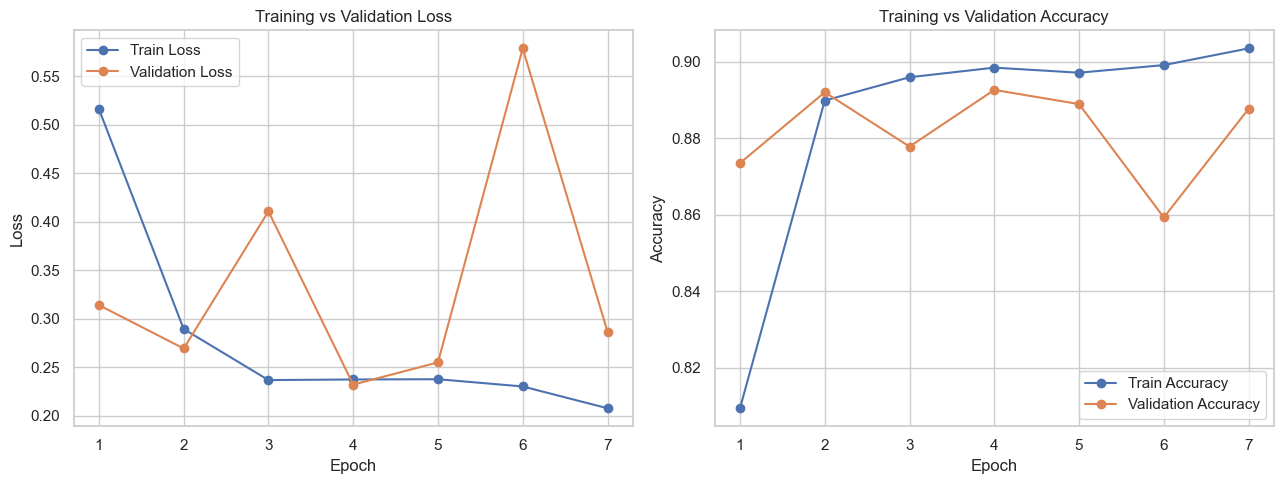

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Validation Accuracy", marker="o")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Phase 16 — Model Evaluation (Transformer)


--- Transformer ---
  accuracy    : 0.8883
  precision   : 0.8903
  recall      : 0.8883
  f1          : 0.8888
  macro_f1    : 0.8888
  weighted_f1 : 0.8888

              precision    recall  f1-score   support

         Low       0.87      0.91      0.89       405
      Medium       0.81      0.83      0.82       405
        High       0.91      0.91      0.91       405
    Critical       0.97      0.90      0.93       405

    accuracy                           0.89      1620
   macro avg       0.89      0.89      0.89      1620
weighted avg       0.89      0.89      0.89      1620



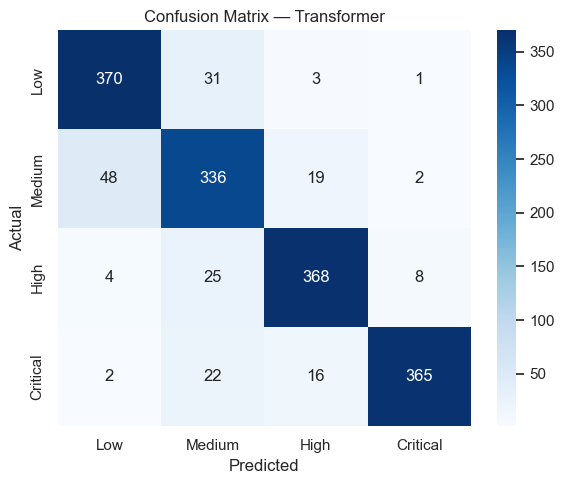

ROC-AUC (macro, one-vs-rest): 0.9886


In [ ]:
def get_predictions(loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device)
            logits = model(input_ids)
            probs = F.softmax(logits, dim=1)
            all_preds.append(probs.argmax(dim=1).cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return (np.concatenate(all_preds), np.concatenate(all_labels), np.concatenate(all_probs))


test_preds, test_labels, test_probs = get_predictions(test_loader)

transformer_result = evaluate_predictions(test_labels, test_preds, "Transformer")

try:
    test_labels_onehot = np.eye(NUM_CLASSES)[test_labels]
    roc_auc_ovr = roc_auc_score(test_labels_onehot, test_probs, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro, one-vs-rest): {roc_auc_ovr:.4f}")
    transformer_result["roc_auc_macro_ovr"] = round(float(roc_auc_ovr), 4)
except Exception as e:
    print("ROC-AUC could not be computed:", e)


In [ ]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    test_labels, test_preds, labels=list(range(NUM_CLASSES)), zero_division=0
)
per_class_metrics = pd.DataFrame({
    "severity": SEVERITY_ORDER,
    "precision": per_class_precision.round(4),
    "recall": per_class_recall.round(4),
    "f1": per_class_f1.round(4),
    "support": per_class_support,
})
print("Per-Class Metrics")
display(per_class_metrics)


Per-Class Metrics


,severity,precision,recall,f1,support
0,Low,0.8726,0.9136,0.8926,405
1,Medium,0.8116,0.8296,0.8205,405
2,High,0.9064,0.9086,0.9075,405
3,Critical,0.9707,0.9012,0.9347,405


## Phase 17 — Severity Analysis (confusion patterns, confidence, boundary cases)


In [ ]:
results_df = test_df.copy().reset_index(drop=True)
results_df["true_id"] = test_labels
results_df["pred_id"] = test_preds
results_df["true_label"] = results_df["true_id"].map(ID_TO_SEVERITY)
results_df["pred_label"] = results_df["pred_id"].map(ID_TO_SEVERITY)
results_df["confidence"] = test_probs.max(axis=1)
results_df["correct"] = results_df["true_id"] == results_df["pred_id"]

adjacent_pairs = [("Low", "Medium"), ("Medium", "High"), ("High", "Critical")]
print("Adjacent-Severity Confusion Counts")
print("=" * 45)
for a, b in adjacent_pairs:
    ab = ((results_df["true_label"] == a) & (results_df["pred_label"] == b)).sum()
    ba = ((results_df["true_label"] == b) & (results_df["pred_label"] == a)).sum()
    print(f"{a:10s} -> {b:10s}: {ab:4d}   |   {b:10s} -> {a:10s}: {ba:4d}")


Adjacent-Severity Confusion Counts
Low        -> Medium    :   31   |   Medium     -> Low       :   48
Medium     -> High      :   19   |   High       -> Medium    :   25
High       -> Critical  :    8   |   Critical   -> High      :   16


In [ ]:
misclassified = results_df[~results_df["correct"]]
misclass_pairs = misclassified.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False)
print("Most Common Misclassifications")
display(misclass_pairs.head(10))


Most Common Misclassifications


true_label  pred_label
Medium      Low           48
Low         Medium        31
High        Medium        25
Critical    Medium        22
Medium      High          19
Critical    High          16
High        Critical       8
            Low            4
Low         High           3
Critical    Low            2
dtype: int64

Confidence Analysis
          count      mean       std       min       25%       50%       75%  \
correct                                                                       
False     181.0  0.569204  0.135766  0.361301  0.463126  0.532681  0.655980   
True     1439.0  0.953626  0.135167  0.368708  0.999243  0.999805  0.999908   

              max  
correct            
False    0.992117  
True     0.999990  



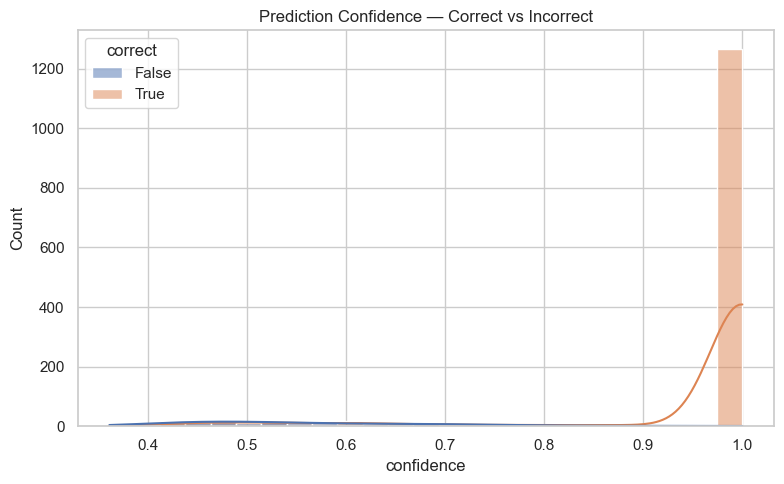

In [ ]:
print("Confidence Analysis")
print(results_df.groupby("correct")["confidence"].describe())
print()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=results_df, x="confidence", hue="correct", bins=25, kde=True, ax=ax)
ax.set_title("Prediction Confidence — Correct vs Incorrect")
plt.tight_layout()
plt.show()


In [ ]:
print("Worst Predictions (confident but wrong)")
worst = misclassified.sort_values("confidence", ascending=False).head(10)
display(worst[["review_text", "true_label", "pred_label", "confidence"]])

print()
print("Most Uncertain Predictions (lowest confidence)")
uncertain = results_df.sort_values("confidence", ascending=True).head(10)
display(uncertain[["review_text", "true_label", "pred_label", "confidence"]])

print()
print("Severity Boundary Cases (true/pred are adjacent severities)")
severity_rank = {s: i for i, s in enumerate(SEVERITY_ORDER)}
boundary_mask = (
    ~results_df["correct"]
    & (results_df["true_label"].map(severity_rank) - results_df["pred_label"].map(severity_rank)).abs().eq(1)
)
boundary_cases = results_df[boundary_mask]
print(f"Boundary-case count: {len(boundary_cases)} / {len(misclassified)} misclassifications")
display(boundary_cases[["review_text", "true_label", "pred_label", "confidence"]].head(10))


Worst Predictions (confident but wrong)


,review_text,true_label,pred_label,confidence
1441,"The chairs were incredibly uncomfortable, hard...",Medium,Low,0.992117
1114,"I really wanted to like this place, but the fi...",Critical,High,0.977685
267,"All things considered, the bill came out rough...",Medium,Low,0.974262
1035,A surprise convenience fee showed up on the fi...,High,Critical,0.949408
1350,"I have to say, our booking seemed to have vani...",High,Low,0.948012
342,"To be fair, our table hadn't been wiped down a...",Medium,Low,0.886858
1358,"To be fair, I specifically asked for no onions...",High,Critical,0.870793
165,"To be fair, overall it was an average experien...",Medium,Low,0.856269
501,"Honestly, for the price, the tomato soup porti...",Low,Medium,0.852595
655,"Honestly, the bill came out roughly as expecte...",Medium,Low,0.836406



Most Uncertain Predictions (lowest confidence)


,review_text,true_label,pred_label,confidence
1045,"I've visited a few times before, and I noticed...",High,Medium,0.361301
846,"Not going to lie, we waited almost 45 minutes ...",High,High,0.368708
863,"I've visited a few times before, and my cappuc...",Critical,Medium,0.373911
1418,"To be fair, I have a nut allergy and the garde...",Critical,High,0.376461
233,"I have to say, the tone the technician used wi...",Medium,Medium,0.381571
478,"I have to say, it looked like the appliance re...",Medium,High,0.384215
1528,"Overall, a fairly middle-of-the-road visit, so...",Medium,Medium,0.385378
61,"I've visited a few times before, and the chick...",Critical,Critical,0.387388
637,It took over an hour before anyone even brough...,High,High,0.394708
1460,"I have to say, I found the behavior of deliver...",High,High,0.398918



Severity Boundary Cases (true/pred are adjacent severities)
Boundary-case count: 147 / 181 misclassifications


,review_text,true_label,pred_label,confidence
5,"To be fair, the water park was reasonably clea...",Medium,Low,0.677354
11,"I noticed several hygiene red flags, from dirt...",High,Medium,0.470377
28,"The restrooms were okay, a little worn but not...",Medium,Low,0.706334
29,"Not going to lie, the cinema hall had clearly ...",Medium,High,0.444860
50,"Overall, overall it was an average experience ...",Medium,Low,0.713360
55,Overall it was an average experience at this r...,Low,Medium,0.542187
68,"All things considered, the duty manager was po...",Medium,Low,0.500124
76,"This was my first time here, and the chicken w...",High,Medium,0.566407
82,"All things considered, overall it was an avera...",Medium,Low,0.802682
88,"Overall, it was fine, I don't have strong feel...",Medium,Low,0.506387


## Phase 18 — Model Comparison


In [ ]:
comparison_df = pd.DataFrame(baseline_results + [transformer_result])
comparison_df = comparison_df[["model", "accuracy", "precision", "recall", "macro_f1", "weighted_f1"]]
comparison_df = comparison_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

print("MODEL COMPARISON")
display(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
print(f"\nBest model by Macro F1: {best_model_name}")


MODEL COMPARISON


,model,accuracy,precision,recall,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression,0.8994,0.9001,0.8994,0.8993,0.8993
1,Transformer,0.8883,0.8903,0.8883,0.8888,0.8888
2,TF-IDF + Random Forest,0.8802,0.8883,0.8802,0.8813,0.8813



Best model by Macro F1: TF-IDF + Logistic Regression


## Phase 19 — Model Saving


In [73]:
import os

os.makedirs(ARTIFACT_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
}, os.path.join(ARTIFACT_DIR, "severity_transformer_model.pth"))
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
}, os.path.join(ARTIFACT_DIR, "severity_transformer_model.pth"))

config = {
    "MAX_LEN": MAX_LEN,
    "MAX_VOCAB_SIZE": MAX_VOCAB_SIZE,
    "EMBED_DIM": EMBED_DIM,
    "NUM_HEADS": NUM_HEADS,
    "NUM_LAYERS": NUM_LAYERS,
    "FF_DIM": FF_DIM,
    "DROPOUT": DROPOUT,
    "NUM_CLASSES": NUM_CLASSES,
    "vocab_size": vocab_size,
    "pad_token": PAD_TOKEN,
    "unk_token": UNK_TOKEN,
    "severity_order": SEVERITY_ORDER,
    "label_to_id": SEVERITY_TO_ID,
    "id_to_label": {str(k): v for k, v in ID_TO_SEVERITY.items()},
}
with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

training_metrics = {
    "history": history,
    "training_duration_sec": round(train_duration_sec, 2),
    "best_val_loss": round(float(best_val_loss), 4),
    "test_metrics": transformer_result,
    "cross_validation": cv_summary,
    "baseline_results": baseline_results,
    "model_comparison": comparison_df.to_dict(orient="records"),
}
with open(os.path.join(ARTIFACT_DIR, "training_metrics.json"), "w") as f:
    json.dump(training_metrics, f, indent=2, default=float)

with open(os.path.join(ARTIFACT_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
with open(os.path.join(ARTIFACT_DIR, "logistic_regression.pkl"), "wb") as f:
    pickle.dump(log_reg, f)
with open(os.path.join(ARTIFACT_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(random_forest, f)

print("Saved artifacts to:", ARTIFACT_DIR)
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    fpath = os.path.join(ARTIFACT_DIR, fname)
    print(f"  {fname:35s} {os.path.getsize(fpath)/1024:.1f} KB")


Saved artifacts to: Model/Severity_Prediction/artifacts
  config.json                         0.5 KB
  logistic_regression.pkl             190.5 KB
  random_forest.pkl                   10157.2 KB
  severity_transformer_model.pth      7605.8 KB
  tfidf_vectorizer.pkl                242.3 KB
  training_metrics.json               2.3 KB


## Phase 20 — Inference Functions


In [ ]:
def predict_severity(text, model=model, vocab=vocab, device=device):
    """Predict severity for a single review. Returns severity, confidence, and full probability breakdown."""
    model.eval()
    cleaned = clean_text(text)
    ids = encode_text(cleaned, vocab, MAX_LEN)
    input_tensor = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_id = int(probs.argmax())
    return {
        "severity": ID_TO_SEVERITY[pred_id],
        "confidence": float(probs[pred_id]),
        "probabilities": {ID_TO_SEVERITY[i]: float(p) for i, p in enumerate(probs)},
    }


def predict_batch(texts, model=model, vocab=vocab, device=device, batch_size=32):
    """Predict severity for a list of reviews."""
    model.eval()
    results = []
    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        cleaned = [clean_text(t) for t in chunk]
        ids_batch = [encode_text(c, vocab, MAX_LEN) for c in cleaned]
        input_tensor = torch.tensor(ids_batch, dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(input_tensor)
            probs = F.softmax(logits, dim=1).cpu().numpy()

        for row_probs in probs:
            pred_id = int(row_probs.argmax())
            results.append({
                "severity": ID_TO_SEVERITY[pred_id],
                "confidence": float(row_probs[pred_id]),
                "probabilities": {ID_TO_SEVERITY[i]: float(p) for i, p in enumerate(row_probs)},
            })
    return results


sample_review = "The food arrived cold, the server was rude, and I found a hair in my soup. Never coming back."
print("Single prediction:")
print(json.dumps(predict_severity(sample_review), indent=2))

print()
print("Batch prediction:")
batch_samples = test_df["review_text"].head(3).tolist()
for text, pred in zip(batch_samples, predict_batch(batch_samples)):
    print("-" * 60)
    print("Review:", text[:100])
    print("Prediction:", pred["severity"], f"(confidence {pred['confidence']:.3f})")


## Phase 21 — Deployment Preparation (Flask / FastAPI / Render / Vercel)


In [ ]:
DEPLOY_DIR = "deployment"
os.makedirs(DEPLOY_DIR, exist_ok=True)

model_definition_code = '''"""Shared model definition + loading utilities for deployment."""
import json
import pickle
import re
import unicodedata

import torch
import torch.nn as nn
import torch.nn.functional as F

HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\\S+|www\\.\\S+")
EMAIL_RE = re.compile(r"\\S+@\\S+\\.\\S+")
MULTISPACE_RE = re.compile(r"\\s+")
SPECIAL_CHARS_RE = re.compile(r"[^a-z0-9\\s.,!?\'\\-]")


def clean_text(text):
    text = str(text).lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = SPECIAL_CHARS_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]
            scores = scores.masked_fill(mask, float("-inf"))
        attn = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, embed_dim)
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, ff_dim, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        x = self.norm1(x + self.dropout(self.attn(x, key_padding_mask=key_padding_mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        B, T, _ = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        return x + self.pos_embedding(positions)


class SeverityTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, dropout, num_classes, max_len, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim)
        self.embed_dropout = nn.Dropout(dropout)
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )

    def forward(self, input_ids):
        padding_mask = input_ids == self.pad_idx
        x = self.token_embedding(input_ids)
        x = self.positional_embedding(x)
        x = self.embed_dropout(x)
        for block in self.encoder_blocks:
            x = block(x, key_padding_mask=padding_mask)
        mask = (~padding_mask).unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        return self.classifier(pooled)


def encode_text(text, vocab, max_len, unk_token="<unk>", pad_token="<pad>"):
    tokens = text.split()[:max_len]
    ids = [vocab.get(tok, vocab[unk_token]) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab[pad_token]] * (max_len - len(ids))
    return ids


def load_artifacts(artifact_dir="artifacts", device="cpu"):
    """Load config, vocab, label encoder, and trained weights for inference."""
    with open(f"{artifact_dir}/config.json") as f:
        config = json.load(f)
    with open(f"{artifact_dir}/severity_vocab.pkl", "rb") as f:
        vocab_bundle = pickle.load(f)
    with open(f"{artifact_dir}/severity_label_encoder.pkl", "rb") as f:
        label_bundle = pickle.load(f)

    model = SeverityTransformer(
        vocab_size=config["vocab_size"], embed_dim=config["EMBED_DIM"], num_heads=config["NUM_HEADS"],
        num_layers=config["NUM_LAYERS"], ff_dim=config["FF_DIM"], dropout=config["DROPOUT"],
        num_classes=config["NUM_CLASSES"], max_len=config["MAX_LEN"],
    )
    checkpoint = torch.load(f"{artifact_dir}/severity_transformer_model.pth", map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return {
        "model": model,
        "config": config,
        "vocab": vocab_bundle["vocab"],
        "id_to_label": {int(k): v for k, v in label_bundle["id_to_label"].items()},
        "device": device,
    }


def predict(text, bundle):
    """Run inference on a single text using a bundle from load_artifacts()."""
    cleaned = clean_text(text)
    ids = encode_text(cleaned, bundle["vocab"], bundle["config"]["MAX_LEN"])
    input_tensor = torch.tensor([ids], dtype=torch.long).to(bundle["device"])
    with torch.no_grad():
        logits = bundle["model"](input_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(probs.argmax())
    return {
        "severity": bundle["id_to_label"][pred_id],
        "confidence": float(probs[pred_id]),
        "probabilities": {bundle["id_to_label"][i]: float(p) for i, p in enumerate(probs)},
    }
'''

with open(os.path.join(DEPLOY_DIR, "model_utils.py"), "w") as f:
    f.write(model_definition_code)

print("Wrote deployment/model_utils.py (shared model + preprocessing + loader)")


In [ ]:
flask_app_code = '''"""Flask deployment entrypoint. Run: gunicorn app:app  (or) python app.py"""
from flask import Flask, request, jsonify
from model_utils import load_artifacts, predict

app = Flask(__name__)
BUNDLE = load_artifacts(artifact_dir="artifacts", device="cpu")


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


@app.route("/predict", methods=["POST"])
def predict_route():
    payload = request.get_json(force=True) or {}
    text = payload.get("text", "")
    if not text:
        return jsonify({"error": "\'text\' field is required"}), 400
    return jsonify(predict(text, BUNDLE))


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''
with open(os.path.join(DEPLOY_DIR, "flask_app.py"), "w") as f:
    f.write(flask_app_code)


fastapi_app_code = '''"""FastAPI deployment entrypoint. Run: uvicorn fastapi_app:app --host 0.0.0.0 --port 5000"""
from fastapi import FastAPI
from pydantic import BaseModel
from model_utils import load_artifacts, predict

app = FastAPI(title="Restaurant Complaint Severity API")
BUNDLE = load_artifacts(artifact_dir="artifacts", device="cpu")


class PredictRequest(BaseModel):
    text: str


@app.get("/health")
def health():
    return {"status": "ok"}


@app.post("/predict")
def predict_route(payload: PredictRequest):
    return predict(payload.text, BUNDLE)
'''
with open(os.path.join(DEPLOY_DIR, "fastapi_app.py"), "w") as f:
    f.write(fastapi_app_code)


render_yaml = '''services:
  - type: web
    name: severity-api
    env: python
    buildCommand: pip install -r deployment_requirements.txt
    startCommand: gunicorn -w 2 -b 0.0.0.0:$PORT flask_app:app
'''
with open(os.path.join(DEPLOY_DIR, "render.yaml"), "w") as f:
    f.write(render_yaml)


vercel_json = '''{
  "version": 2,
  "builds": [{ "src": "fastapi_app.py", "use": "@vercel/python" }],
  "routes": [{ "src": "/(.*)", "dest": "fastapi_app.py" }]
}'''
with open(os.path.join(DEPLOY_DIR, "vercel.json"), "w") as f:
    f.write(vercel_json)

print("Wrote deployment/flask_app.py, deployment/fastapi_app.py, deployment/render.yaml, deployment/vercel.json")


In [ ]:
import shutil

for fname in ["severity_transformer_model.pth", "severity_vocab.pkl", "severity_label_encoder.pkl", "config.json"]:
    shutil.copy(os.path.join(ARTIFACT_DIR, fname), os.path.join(DEPLOY_DIR, fname))

print("Copied deployment-required artifacts into", DEPLOY_DIR)
print(sorted(os.listdir(DEPLOY_DIR)))


## Phase 22 — Python 3.11 Requirements Generation


In [ ]:
requirements_txt = '''# Full development/training environment (Python 3.11.x)
numpy>=1.26,<2.5
pandas>=2.2,<3.1
scikit-learn>=1.4,<1.10
matplotlib>=3.8,<3.12
seaborn>=0.13,<0.14
wordcloud>=1.9,<1.10
torch>=2.2,<2.14
jupyter>=1.0
nbformat>=5.10
nbclient>=0.10
ipykernel>=6.29
'''
with open("requirements.txt", "w") as f:
    f.write(requirements_txt)

deployment_requirements_txt = '''# Minimal inference-only environment for deployment (Python 3.11.x)
# Compatible with Replit, Render, Vercel, macOS (M1/M2/M3), Windows, Linux
torch>=2.2,<2.14
numpy>=1.26,<2.5
flask>=3.0,<3.2
fastapi>=0.110,<0.120
uvicorn>=0.29,<0.35
gunicorn>=21.2,<23.1
pydantic>=2.6,<2.11
'''
with open("deployment_requirements.txt", "w") as f:
    f.write(deployment_requirements_txt)

print("Wrote requirements.txt and deployment_requirements.txt")
print()
print(requirements_txt)
print(deployment_requirements_txt)


## Summary

- **Best traditional baseline vs. custom Transformer** are compared in Phase 18.
- All artifacts needed for deployment are saved under `artifacts/` and mirrored
  into `deployment/` alongside ready-to-run Flask and FastAPI entrypoints.
- Use `predict_severity(text)` / `predict_batch(texts)` (Phase 20) for quick
  in-notebook inference, or `deployment/model_utils.py` for a standalone
  production loader (`load_artifacts()` + `predict()`).
